<a href="https://www.kaggle.com/code/samirmidris/predict-customer-churn-competition-baseline?scriptVersionId=301177330" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predict Customer Churn Competition, Baseline Solution

## Competition URL: https://www.kaggle.com/competitions/playground-series-s6e3

This baseline utilizes XGBoost's native categorical support and basic TotalCharges cleaning to establish a stable ~0.914 score, serving as the essential foundation upon which more advanced ensembling or feature engineering is built.

Author:<br>
Samir M. Idris<br>
Senior Software Engineer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("All backages loaded successfully.")

All backages loaded successfully.


In [2]:
# ====================================================
# 1. VISUAL SETTINGS (For the "Pro" Look)
# ====================================================
plt.style.use('fivethirtyeight')
sns.set_palette("husl")

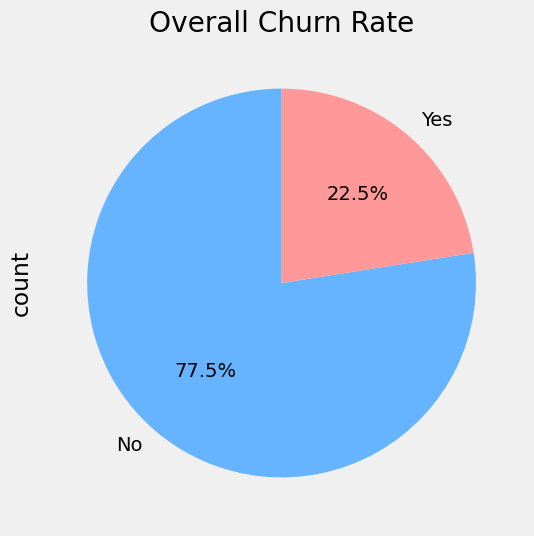

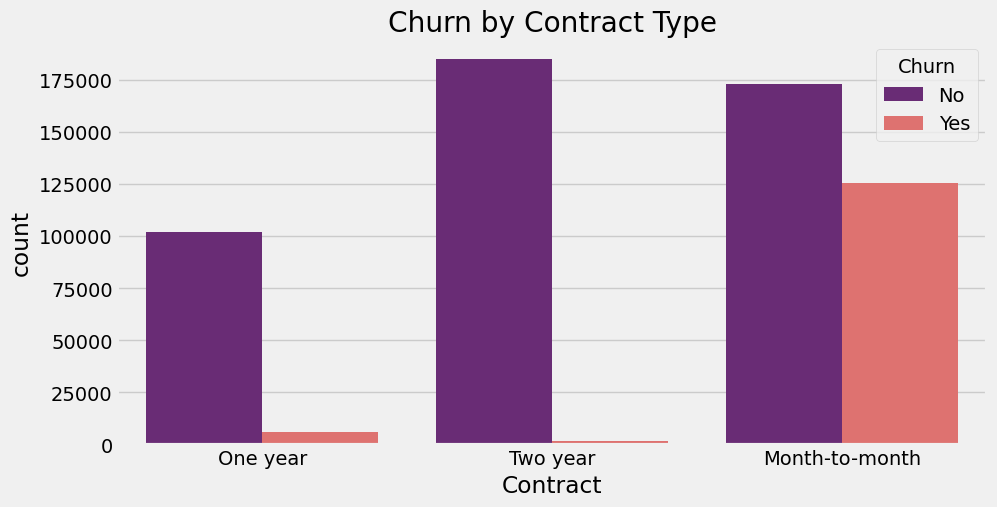

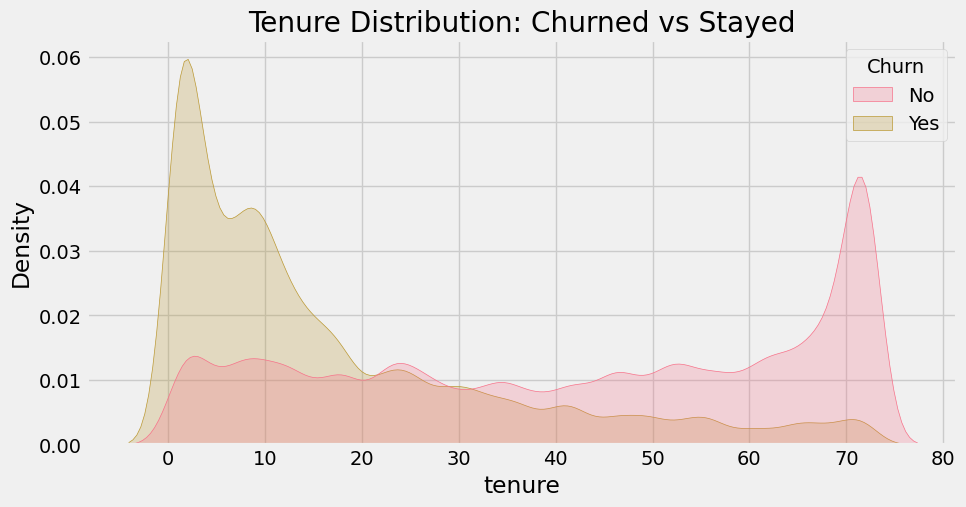

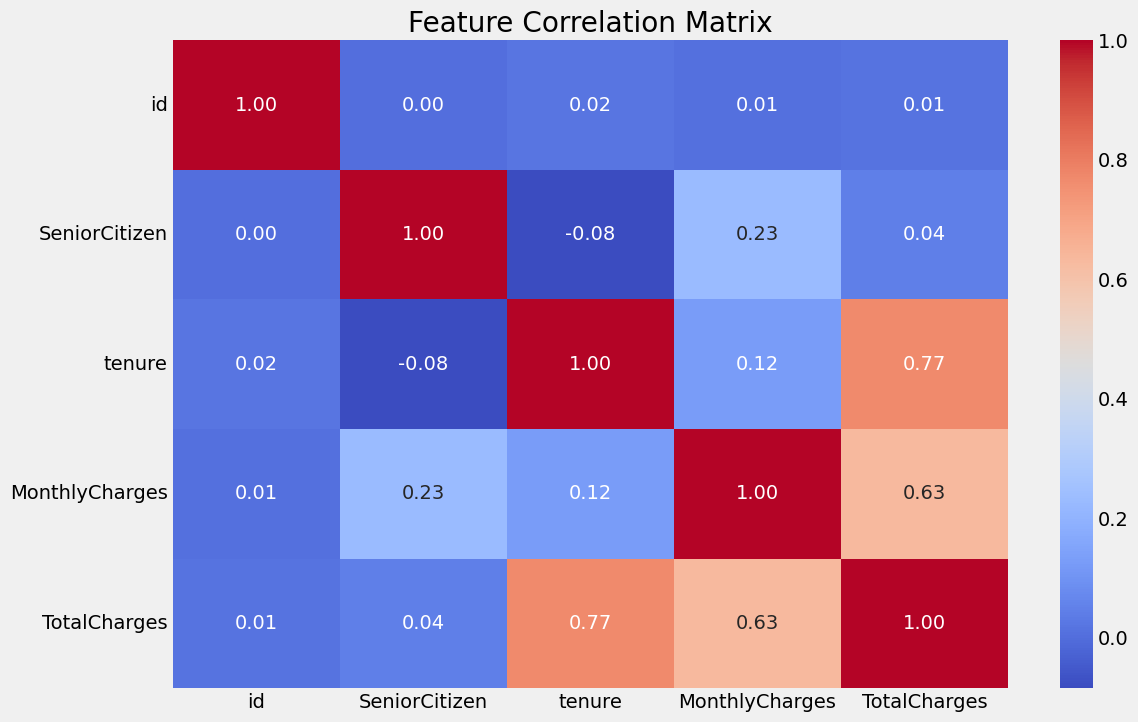

/tmp/ipykernel_55/1810706413.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=train, palette='Set2')


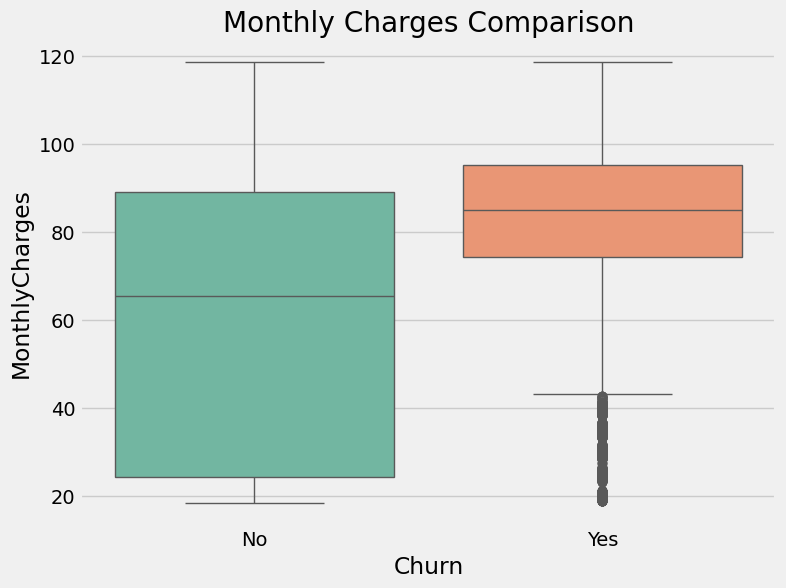

In [3]:
# ====================================================
# 2. DATA LOADING & QUICK EDA
# ====================================================
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

# Visualizing Churn Distribution:

# 1. Churn Distribution Pie Chart
plt.figure(figsize=(6, 6))
train['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Overall Churn Rate')
plt.show()

# 2. Contract Type vs Churn Bar Chart
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=train, palette='magma')
plt.title('Churn by Contract Type')
plt.show()

# 3. Tenure KDE Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.title('Tenure Distribution: Churned vs Stayed')
plt.show()

# 4. Correlation Heatmap (Numeric Only)
plt.figure(figsize=(12, 8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

# 5. Monthly Charges Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=train, palette='Set2')
plt.title('Monthly Charges Comparison')
plt.show()

In [18]:
# ====================================================
# 3. FEATURE ENGINEERING
# ====================================================
def engineer_features(df):
    df = df.copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(df['MonthlyCharges'] * df['tenure'])
    
    # New Insights
    df['Monthly_Ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
    df['Service_Diversity'] = (df[['OnlineSecurity', 'DeviceProtection', 'TechSupport']] == 'Yes').sum(axis=1)
    df['Is_Senior_Fiber'] = ((df['SeniorCitizen'] == 1) & (df['InternetService'] == 'Fiber optic')).astype(int)
    
    for col in df.select_dtypes('object').columns:
        df[col] = df[col].astype('category')
    return df

train_df = engineer_features(train)
test_df = engineer_features(test)

X = train_df.drop(columns=['id', 'Churn'])
y = train_df['Churn'].map({'No': 0, 'Yes': 1})
X_test = test_df.drop(columns=['id'])

print("Feature Engineering: DONE!")

Feature Engineering: DONE!


In [19]:
# ====================================================
# 4. CROSS-VALIDATION LOOP
# ====================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds = np.zeros(len(test))
importances = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=4, 
                          tree_method='hist', device='cuda', enable_categorical=True)
    
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
    test_preds += model.predict_proba(X_test)[:, 1] / 5
    importances.append(model.feature_importances_)

print ("CV DONE!")

[0]	validation_0-logloss:0.51416
[100]	validation_0-logloss:0.30502
[200]	validation_0-logloss:0.30165
[300]	validation_0-logloss:0.30031
[400]	validation_0-logloss:0.29963
[500]	validation_0-logloss:0.29922
[600]	validation_0-logloss:0.29889
[700]	validation_0-logloss:0.29869
[800]	validation_0-logloss:0.29854
[900]	validation_0-logloss:0.29848
[999]	validation_0-logloss:0.29841


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [11:22:24] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[0]	validation_0-logloss:0.51398
[100]	validation_0-logloss:0.30315
[200]	validation_0-logloss:0.29967
[300]	validation_0-logloss:0.29847
[400]	validation_0-logloss:0.29773
[500]	validation_0-logloss:0.29727
[600]	validation_0-logloss:0.29693
[700]	validation_0-logloss:0.29675
[800]	validation_0-logloss:0.29658
[900]	validation_0-logloss:0.29648
[999]	validation_0-logloss:0.29639
[0]	validation_0-logloss:0.51406
[100]	validation_0-logloss:0.30455
[200]	validation_0-logloss:0.30121
[300]	validation_0-logloss:0.30011
[400]	validation_0-logloss:0.29932
[500]	validation_0-logloss:0.29883
[600]	validation_0-logloss:0.29848
[700]	validation_0-logloss:0.29826
[800]	validation_0-logloss:0.29808
[900]	validation_0-logloss:0.29797
[999]	validation_0-logloss:0.29787
[0]	validation_0-logloss:0.51405
[100]	validation_0-logloss:0.30254
[200]	validation_0-logloss:0.29931
[300]	validation_0-logloss:0.29805
[400]	validation_0-logloss:0.29743
[500]	validation_0-logloss:0.29708
[600]	validation_0-logloss

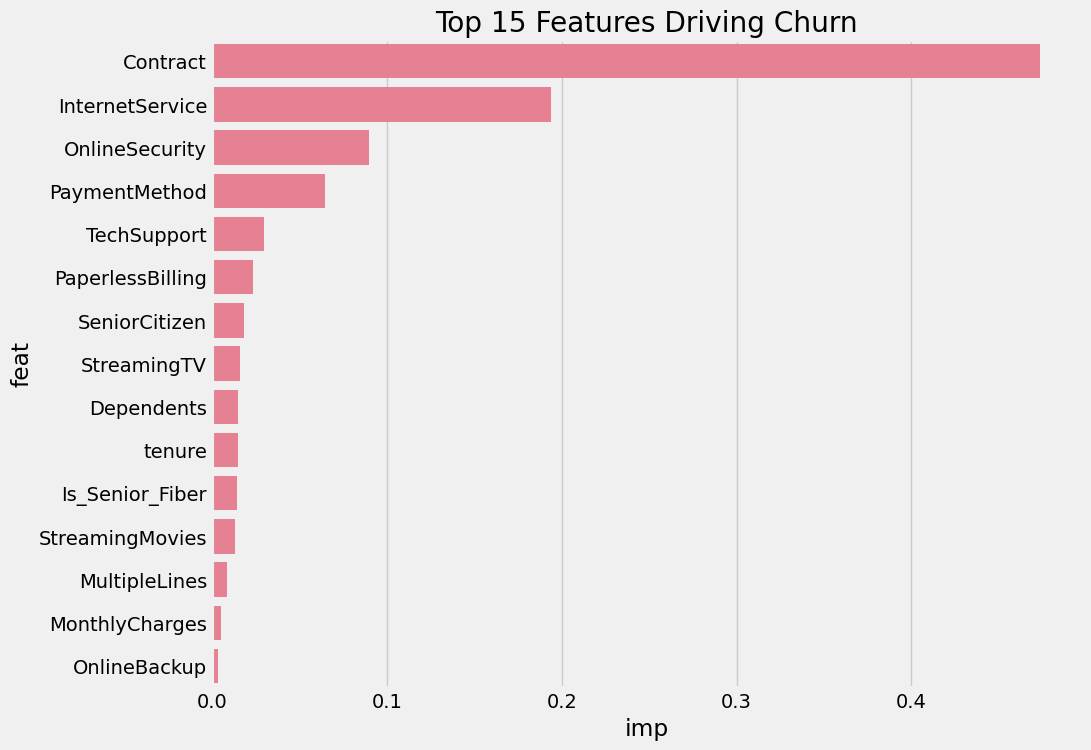

submission.csv file is ready!


In [22]:
# ====================================================
# 5. FEATURE IMPORTANCE (Upvote Magnet #2)
# ====================================================
fi_df = pd.DataFrame({'feat': X.columns, 'imp': np.mean(importances, axis=0)}).sort_values('imp', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df.head(15), x='imp', y='feat')
plt.title('Top 15 Features Driving Churn')
plt.show()

pd.DataFrame({'id': test['id'], 'Churn': test_preds}).to_csv('submission.csv', index=False)
print("submission.csv file is ready!")